# Pipeline B Phase 2 — UK Political Reddit Virality

## Objective
Apply the virality prediction framework established on Fakeddit (US) to 
UK political Reddit. Key additions over the US pipeline: UK-specific 
political leaning features, Antypas trigger words, BERTopic topic features, 
and BERT-predicted veracity labels (replacing ground-truth is_fake).

## Data
- Source: Pushshift dumps, r/ukpolitics + r/LabourUK + r/tories + r/reformuk 
  + r/uknews, July–September 2024
- Rationale: captures 2024 general election, Southport riots, and aftermath 
  — an unusually concentrated period of UK political misinformation activity

## Feature matrix additions over US pipeline

| Feature | Source | Citation |
| :--- | :--- | :--- |
| Trigger words (NHS, Brexit, Rwanda, Vaccine, Feminism) | Keyword flags | Antypas et al. (2026) |
| Political leaning ratio (left/right keyword density) | Keyword ratio | Antypas et al. (2026) |
| BERTopic topic assignments (top 10 topics) | BERTopic on UK corpus | Grootendorst (2022) |
| p_fake, p_true | BERT Pipeline A checkpoint | Nakamura et al. (2019) |

## Key differences from US pipeline
- No ground-truth veracity labels — BERT predictions used instead
- hasImage engineered from URL (not native to Pushshift dumps)
- Timezone converted to GMT not US Central
- Political leaning meaningful in UK context; US keyword ratio dropped
- Topic features from UK corpus only (BERTopic fit on UK train, applied to val/test)

## Research questions
- Does p_fake rank higher as a virality predictor on UK political Reddit 
  than on general US Reddit (where is_fake ranked 2nd but suppressed virality)?
- Which trigger words drive virality, and do they interact with veracity?
- Do viral fake and viral true posts succeed for different reasons in a 
  UK political context?

## 0. Imports and data loading 

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np


from datetime import datetime
from zoneinfo import ZoneInfo

from urllib.parse import urlparse

import torch
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from tqdm import tqdm
from datasets import Dataset
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import subprocess
import time
from nrclex import NRCLex
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              average_precision_score, f1_score,
                              precision_recall_curve, ConfusionMatrixDisplay,
                              confusion_matrix)


from pathlib import Path
import xgboost
import shap
import scipy.special

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/katechamberlain/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
dir = '../data/processed/UK/'
train_df = pd.read_csv(f'{dir}train.csv')
val_df = pd.read_csv(f'{dir}val.csv')
test_df = pd.read_csv(f'{dir}test.csv')

In [3]:
train_df.head()

,id,created_utc,subreddit,title,selftext,score,num_comments,url,1dbpdeg,1717923261.0,unitedkingdom,Man with 'explosive disorder' attacked woman in row over puppies,[removed],1,0,https://www.nottinghampost.com/news/local-news/sandiacre-man-explosive-disorder-attacked-9329811,combined_text,word_count
0,1f9mwmn,1.725544e+09,ukpolitics,‘Broke’ Tories slashing jobs at HQ as donation...,NaN,1.0,1.0,https://inews.co.uk/news/politics/broke-tories...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,‘Broke’ Tories slashing jobs at HQ as donation...,12
1,1at5vsr,1.708187e+09,LabourUK,New Labour MP is married to former Israeli spy...,NaN,2.0,6.0,https://electronicintifada.net/blogs/asa-winst...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New Labour MP is married to former Israeli spy...,10
2,1gk1aiu,1.730791e+09,ukpolitics,Plans for biggest onshore windfarm in England ...,NaN,103.0,47.0,https://www.theguardian.com/environment/2024/n...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Plans for biggest onshore windfarm in England ...,12
3,1atubkw,1.708264e+09,unitedkingdom,"Taunts, bullying… then groping: how sexual ass...",NaN,123.0,164.0,https://www.theguardian.com/society/2024/feb/1...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Taunts, bullying… then groping: how sexual ass...",11
4,18wmw5r,1.704193e+09,unitedkingdom,Big Boobs Beautiful Girls,NaN,1.0,0.0,https://xnxxvedio24.blogspot.com/2024/01/big-b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Big Boobs Beautiful Girls,4


In [4]:
all_dfs = {'train_df': train_df, 'val_df': val_df, 'test_df': test_df}

for name, df in all_dfs.items():
    subreddit_dist = df['subreddit'].value_counts(normalize=True)
    nulls = df.isnull().mean()
    
    print(f'{name}:')
    print(f'{len(df)} rows')
    print(f'Subreddit distribution: \n{subreddit_dist}\n')
    print(f'Null counts:\n {nulls}')


train_df:
80416 rows
Subreddit distribution: 
subreddit
unitedkingdom      0.512261
ukpolitics         0.253482
LabourUK           0.081949
policeuk           0.075669
uknews             0.041994
tories             0.013890
reformuk           0.010694
brexit             0.007697
BritishPolitics    0.001766
gbnews             0.000473
GreenPartyUK       0.000124
Name: proportion, dtype: float64

Null counts:
 id                                                                                                  0.000000
created_utc                                                                                         0.000000
subreddit                                                                                           0.000000
title                                                                                               0.000000
selftext                                                                                            0.616619
score                                      

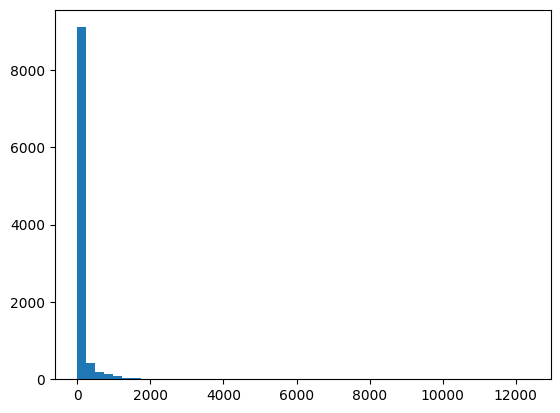

In [5]:
# check distribution of raw engagement scores
plt.hist(df['num_comments'] + df['score'], bins=50)
plt.show()

## 1 Virality target construction 

In [6]:
def calculate_engagement_metric(df, train_percentile_cap=None, train_subreddit_stats=None):
    """
    Computes each reddit post's normalised engagement score using log z-score within subreddit

    Parameters 
    ----------
    train_percentile_cap : float, optional
        Pre-computed 99th percentile from training set.
        None = compute from this df (use only for train split).
    train_subreddit_stats : dict, optional
        Pre-computed {'mean': Series, 'std': Series} from training set.
        None = compute from this df (use only for train split).
    
    Returns 
    ----------
    df : DataFrame with engagement score column added
    cap_value : 99th percentile threshold (reuse for val/test)
    subreddit_stats : dict of train set subreddit means and stds 

    """

    df = df.copy()

    # raw engagement = num comments + score (num upvotes)
    df['raw_engagement'] = df['num_comments'].fillna(0).clip(lower=0) + df['score'].fillna(0).clip(lower=0)

    # log transform 
    df['log_raw_engagement'] = np.log1p(df['raw_engagement'])

    # z-score within subreddit 
    if train_subreddit_stats is None:   # must be train split to prevent data leakage  - computing threshold 
        sub_means = df.groupby(['subreddit'])['log_raw_engagement'].mean()
        sub_stds = df.groupby(['subreddit'])['log_raw_engagement'].std(ddof=0).fillna(0)
        subreddit_stats = {'mean': sub_means, 'std': sub_stds}
    else:
        subreddit_stats = train_subreddit_stats

    df['sub_mean'] = df['subreddit'].map(subreddit_stats['mean'])
    df['sub_std'] = df['subreddit'].map(subreddit_stats['std'])

    # handle subreddits unseen in training data - fill with total population stats
    df['sub_mean'] = df['sub_mean'].fillna(df['log_raw_engagement'].mean())
    df['sub_std'] = df['sub_std'].fillna(df['log_raw_engagement'].std())

    df['normalised_engagement'] = (df['log_raw_engagement'] - df['sub_mean'])/(df['sub_std'] + 1e-8) # add v small number to avoid dividing by zero when subreddits only have 1 post

    # apply percentile outlier cap to reduce the effects of outliers on k-means. Train set threshold applied to all splits
    if train_percentile_cap is None:
        cap_value = df['normalised_engagement'].quantile(0.99)
    else: 
        cap_value = train_percentile_cap

    df['capped_engagement'] = np.minimum(df['normalised_engagement'], cap_value) # use what's smaller of engagement number or percentile cap 

    # remove intermediate cols
    df = df.drop(columns=['sub_mean', 'sub_std'])
    
    return df, cap_value, subreddit_stats


In [7]:
def apply_virality_threshold(df, train_percentile_cap=None,
                              train_subreddit_stats=None,
                              train_threshold=None,
                              viral_percentile=0.80,
                              graph=True):
    df, cap_value, subreddit_stats = calculate_engagement_metric(
        df,
        train_percentile_cap=train_percentile_cap,
        train_subreddit_stats=train_subreddit_stats,
    )

    if train_threshold is None:
        threshold = df['capped_engagement'].quantile(viral_percentile)
    else:
        threshold = train_threshold

    df['is_viral'] = (df['capped_engagement'] >= threshold).astype(int)

    print(f'Virality threshold (z-score): {threshold:.4f}')
    print(f'Class distribution:\n{df["is_viral"].value_counts(normalize=True).round(3)}')

    if graph:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        df['capped_engagement'].hist(bins=100, ax=axes[0])
        axes[0].axvline(threshold, color='red', linestyle='--',
                        label=f'threshold={threshold:.2f}')
        axes[0].set_title('Normalised engagement distribution')
        axes[0].set_xlabel('z-score (capped)')
        axes[0].legend()

        df['log_raw_engagement'].hist(bins=100, ax=axes[1])
        axes[1].set_title('Log raw engagement distribution')
        axes[1].set_xlabel('log(raw_engagement + 1)')

        plt.tight_layout()
        plt.show()

        overall_mean = df['log_raw_engagement'].mean()
        overall_std  = df['log_raw_engagement'].std()
        approx_raw_eng = np.expm1(threshold * overall_std + overall_mean)
        print(f"Approx raw engagement at threshold: {approx_raw_eng:.0f} (upvotes + comments)")

    # drop intermediate columns after plotting
    df = df.drop(columns=[c for c in ['capped_engagement', 'log_raw_engagement',
                                       'raw_engagement'] if c in df.columns])

    return df, threshold, cap_value, subreddit_stats

Virality threshold (z-score): 1.5465
Class distribution:
is_viral
0    0.9
1    0.1
Name: proportion, dtype: float64


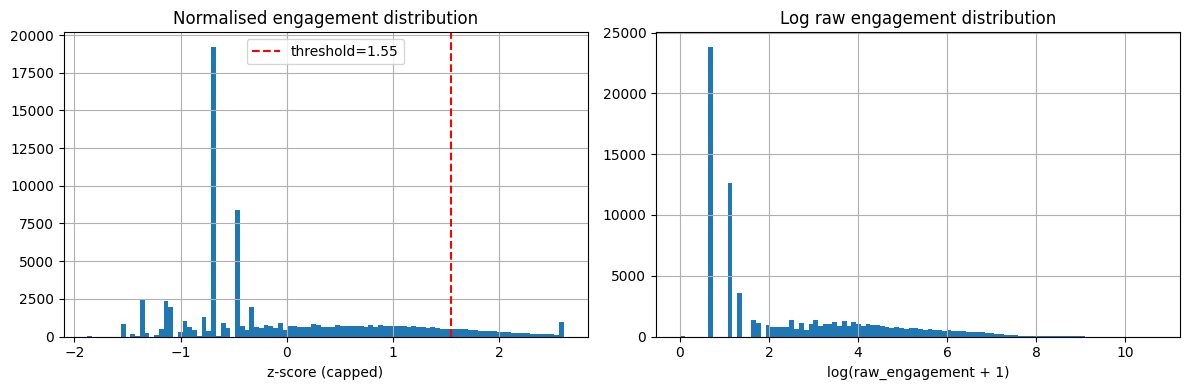

Approx raw engagement at threshold: 231 (upvotes + comments)
Virality threshold (z-score): 1.5465
Class distribution:
is_viral
0    0.895
1    0.105
Name: proportion, dtype: float64
Virality threshold (z-score): 1.5465
Class distribution:
is_viral
0    0.9
1    0.1
Name: proportion, dtype: float64


In [8]:
train_df, threshold, cap_value, sub_stats = apply_virality_threshold(
    train_df, viral_percentile=0.90, graph=True
)

val_df, _, _, _ = apply_virality_threshold(
    val_df,
    train_percentile_cap=cap_value,
    train_subreddit_stats=sub_stats,
    train_threshold=threshold,
    graph=False,
)

test_df, _, _, _ = apply_virality_threshold(
    test_df,
    train_percentile_cap=cap_value,
    train_subreddit_stats=sub_stats,
    train_threshold=threshold,
    graph=False,
)

all_dfs['train_df'] = train_df
all_dfs['val_df'] = val_df
all_dfs['test_df'] = test_df



In [9]:
print(train_df.groupby('subreddit')['is_viral'].agg(['count', 'mean']).sort_values('count'))

                 count      mean
subreddit                       
GreenPartyUK        10  0.100000
gbnews              38  0.105263
BritishPolitics    142  0.077465
brexit             619  0.012924
reformuk           860  0.031395
tories            1117  0.027753
uknews            3377  0.091501
policeuk          6085  0.094166
LabourUK          6590  0.055539
ukpolitics       20384  0.078984
unitedkingdom    41194  0.123853


Notes
- Two big spikes in normalised z-score distribution (z=-075 and z=-0.5). Coming from huge spike at 0.7 in log plot (for posts with raw engagement around 1). 
- Only using 3 mooths of data atm - some subreddits have very few posts, making their z scoring very unreliable (tiny std). **Likely smoothed out when more months of data are introduced**. Stability of subreddit-level engagement stats is limited for smaller communities e.g. GreenPartyUK 
- **Virality threshold at z=1.55, raw enggement=245** - looks reasonable. These posts are genuinely high engagement 


## 2 Feature engineering

### 2.1 Structural metadata

Why use stylometric features (punctuation densities, caps ratio) as well as a sentiment score like VADER? They provide explainability tht a sentiment score may mask because the sentiment score rolls up those contributiong features into a single metric. (find paper to back this up)

**Temporal metadata**

In [10]:
def add_temporal_features(utc_val, timezone='Europe/London'):
    dt = datetime.fromtimestamp(utc_val, tz=ZoneInfo('UTC'))
    local_dt = dt.astimezone(tz=ZoneInfo(timezone))
    return pd.Series({
        'day_of_week': local_dt.weekday(),           # 0=Mon, 6=Sun
        'is_weekend':  int(local_dt.weekday() >= 5), # 1 if Sat/Sun
        'time_of_day': local_dt.hour // 4,           # 0-5 integer bin
    })

for df in [train_df, val_df, test_df]:
    df[['day_of_week', 'is_weekend', 'time_of_day']] = \
        df['created_utc'].apply(add_temporal_features, args=('Europe/London',))

In [11]:
train_df.head()

,id,created_utc,subreddit,title,selftext,score,num_comments,url,1dbpdeg,1717923261.0,...,1,0,https://www.nottinghampost.com/news/local-news/sandiacre-man-explosive-disorder-attacked-9329811,combined_text,word_count,normalised_engagement,is_viral,day_of_week,is_weekend,time_of_day
0,1f9mwmn,1.725544e+09,ukpolitics,‘Broke’ Tories slashing jobs at HQ as donation...,NaN,1.0,1.0,https://inews.co.uk/news/politics/broke-tories...,NaN,NaN,...,NaN,NaN,NaN,‘Broke’ Tories slashing jobs at HQ as donation...,12,-1.124131,0,3,0,3
1,1at5vsr,1.708187e+09,LabourUK,New Labour MP is married to former Israeli spy...,NaN,2.0,6.0,https://electronicintifada.net/blogs/asa-winst...,NaN,NaN,...,NaN,NaN,NaN,New Labour MP is married to former Israeli spy...,10,-0.703259,0,5,1,4
2,1gk1aiu,1.730791e+09,ukpolitics,Plans for biggest onshore windfarm in England ...,NaN,103.0,47.0,https://www.theguardian.com/environment/2024/n...,NaN,NaN,...,NaN,NaN,NaN,Plans for biggest onshore windfarm in England ...,12,0.983624,0,1,0,1
3,1atubkw,1.708264e+09,unitedkingdom,"Taunts, bullying… then groping: how sexual ass...",NaN,123.0,164.0,https://www.theguardian.com/society/2024/feb/1...,NaN,NaN,...,NaN,NaN,NaN,"Taunts, bullying… then groping: how sexual ass...",11,1.829635,1,6,1,3
4,18wmw5r,1.704193e+09,unitedkingdom,Big Boobs Beautiful Girls,NaN,1.0,0.0,https://xnxxvedio24.blogspot.com/2024/01/big-b...,NaN,NaN,...,NaN,NaN,NaN,Big Boobs Beautiful Girls,4,-0.668834,0,1,0,2


**has_image**

- Engineer from `url` column: 1 if URL contains  i.redd.it (images and GIFs), i.imgur.com, v.redd.it (videos), or ends in .jpg/.jpeg/.png/.gif.
- any post tat has visual media (image, GIF, video)

In [12]:
substrings = r'i\.redd\.it|i\.imgur\.com|\.jpg|\.jpeg|\.png|\.gif'

for df in [train_df, val_df, test_df]:
    df['has_image'] = df['url'].str.contains(substrings, case=False, na=False)


In [13]:
train_df['has_image'].value_counts()

has_image
False    75090
True      5326
Name: count, dtype: int64

**Punctuation counts**

- Stylometric feature 
- Normalise counts by text length. Punctuation density is more informative than a raw count
- Looking for: 
    - '?' - high question mark count correlates with engagement-driven posts: they prompt the community to reply, driving up comment numbers, which is a key signal for Reddit's hot ranking algorithm 
    - '!' - Sign of emotional intensity
    - Repeated punctuation (e.g. '!!!' and '???') - telling for high emotional arousal (anger, shock, excitement), which is a strong driver of virality

- **Paper:**

In [14]:
def extract_punctuation_features(df, text_column):

    texts = df[text_column].astype(str).fillna('')

    text_lengths = texts.str.len().apply(lambda x: max(x, 1)) # make text len 1 is it's empty to avoid dividing by 0

    # normalised counts for single punctuation 
    df['q_density'] = texts.apply(lambda x: len(re.findall(r'\?', x))) / text_lengths
    df['excl_density'] = texts.apply(lambda x: len(re.findall(r'!', x))) / text_lengths

    # Any sequence of 2 or more consecutive ? or ! 
    df['repeated_punc_density'] = texts.apply(lambda x: len(re.findall(r'[!?]{2,}', x))) / text_lengths
    # Sequences of mixed ! and ?
    df['mixed_punc_density'] = texts.apply(lambda x: len(re.findall(r'(?:\?!|!\?)', x))) / text_lengths

    return df

for key in all_dfs.keys():
    extract_punctuation_features(all_dfs[key], 'combined_text')

train_df, val_df, test_df = all_dfs['train_df'], all_dfs['val_df'], all_dfs['test_df']

Check sparsity of punctuation feature columns
- Question mark density around 18% - keep
- Other two are much sparser but worth keeping for now

In [15]:
# The features you just engineered
punc_features = ['q_density', 'excl_density', 'repeated_punc_density']


sparsity = (train_df[punc_features] > 0).mean() * 100

for feature, percent in sparsity.items():
    sparsity_pct = 100 - percent
    print(f"[{feature}]")
    print(f"  Used in:     {percent:.2f}% of posts")
    print(f"  Is Sparse:   {sparsity_pct:.2f}% empty/zero rows")
    
    # Quick indicator warning if it's super rare
    if percent < 1.0:
         print("Sparse feature (less than 1% usage)")

[q_density]
  Used in:     17.29% of posts
  Is Sparse:   82.71% empty/zero rows
[excl_density]
  Used in:     3.77% of posts
  Is Sparse:   96.23% empty/zero rows
[repeated_punc_density]
  Used in:     0.88% of posts
  Is Sparse:   99.12% empty/zero rows
Sparse feature (less than 1% usage)


**Caps ratio**

Capitalisation ratio (proportion of upper case letters to total characters). Gives a sense of the urgency of the user e.g. are they shouting 

In [16]:
def extract_caps_ratio(df, text_column):
    texts = df[text_column].astype(str).fillna('')
    text_lengths = texts.str.len().apply(lambda x:max(x, 1))

    uppercase_counts = texts.apply(lambda x: sum(1 for char in x if char.isupper()))

    df['caps_ratio'] = uppercase_counts/text_lengths

    return df

for key in all_dfs.keys():
    all_dfs[key] = extract_caps_ratio(all_dfs[key], 'combined_text')

train_df, val_df, test_df = all_dfs['train_df'], all_dfs['val_df'], all_dfs['test_df']

### 2.1 Domain credibility 

Extract domains from URLs and map them to a political leaning and factuality score from MBFC dataset. 

Label encode the columns so that they can feed into XGBoost. Do not one hot encode because the data would be extremely sparse. also, the categories are ordinal.

In [17]:
# load MBFC dataset
idiamap_mbfc_url = 'https://raw.githubusercontent.com/idiap/Factual-Reporting-and-Political-Bias-Web-Interactions/main/data/mbfc.csv'
mbfc_df = pd.read_csv(idiamap_mbfc_url)
mbfc_df.head()


,source,bias,factual_reporting
0,9news.com,neutral,high
1,nbc11news.com,neutral,high
2,12news.com,neutral,high
3,wibw.com,neutral,high
4,wifr.com,neutral,high


In [18]:
# already cleaned but do again as a safety net
mbfc_df['source_clean'] = (mbfc_df['source']
                           .str.lower()
                           .str.strip()
                           .str.replace('www.', '', regex=False))

bias_map        = dict(zip(mbfc_df['source_clean'], mbfc_df['bias']))
factuality_map  = dict(zip(mbfc_df['source_clean'], mbfc_df['factual_reporting']))

NATIVE_REDDIT_DOMAINS = {'reddit.com', 'v.redd.it', 'i.redd.it', 'i.imgur.com'}

In [19]:
def add_mbfc_features(df, bias_map, factuality_map):
    df = df.copy()

    def extract_domain(url):
        if pd.isna(url) or not str(url).strip():
            return ''
        try:
            # netloc is in form 'www.nytimes.com' or'v.redd.it'
            netloc = urlparse(str(url)).netloc.lower().strip()
            if netloc.startswith('www.'):
                netloc = netloc[4:]
            return netloc
        except Exception:
            return ''
    
    df['domain'] = df['url'].apply(extract_domain)

    # Use MBFC map to get bias and factuality columns
    df['mbfc_bias_str'] = df['domain'].map(bias_map).fillna('unknown_unrated')
    df['mbfc_factuality_str'] = df['domain'].map(factuality_map).fillna('unknown_unrated')

    # Override native domains
    is_native = (
        df['domain'].str.contains(r'self\.', na=False) |
        df['domain'].isin(NATIVE_REDDIT_DOMAINS) |
        (df['domain'] == '')  # Empty domains default to native posts
    )
    df.loc[is_native, ['mbfc_bias_str', 'mbfc_factuality_str']] = 'native_reddit'

    bias_numeric_map = {
        'left': -2, 'left-center': -1, 'neutral': 0, 
        'unknown_unrated': 0, 'native_reddit': 0, 
        'right-center': 1, 'right': 2
    }

    factuality_numeric_map = {
        'low': 1, 'mixed': 2, 'high': 3, 
        'unknown_unrated': 0, 'native_reddit': 0
    }

    df['mbfc_bias_spectrum'] = df['mbfc_bias_str'].map(bias_numeric_map).fillna(0)
    df['mbfc_factuality_score'] = df['mbfc_factuality_str'].map(factuality_numeric_map).fillna(0)
    df['is_external_link'] = (~is_native).astype(int)

    df.drop(columns=['domain', 'mbfc_bias_str', 'mbfc_factuality_str'], inplace=True)

    return df

for key in all_dfs.keys():
    all_dfs[key] = add_mbfc_features(all_dfs[key], bias_map, factuality_map)

train_df, val_df, test_df = all_dfs['train_df'], all_dfs['val_df'], all_dfs['test_df']



In [20]:
train_df.head()

,id,created_utc,subreddit,title,selftext,score,num_comments,url,1dbpdeg,1717923261.0,...,time_of_day,has_image,q_density,excl_density,repeated_punc_density,mixed_punc_density,caps_ratio,mbfc_bias_spectrum,mbfc_factuality_score,is_external_link
0,1f9mwmn,1.725544e+09,ukpolitics,‘Broke’ Tories slashing jobs at HQ as donation...,NaN,1.0,1.0,https://inews.co.uk/news/politics/broke-tories...,NaN,NaN,...,3,False,0.0,0.0,0.0,0.0,0.058824,-1,3,1
1,1at5vsr,1.708187e+09,LabourUK,New Labour MP is married to former Israeli spy...,NaN,2.0,6.0,https://electronicintifada.net/blogs/asa-winst...,NaN,NaN,...,4,False,0.0,0.0,0.0,0.0,0.089286,0,0,1
2,1gk1aiu,1.730791e+09,ukpolitics,Plans for biggest onshore windfarm in England ...,NaN,103.0,47.0,https://www.theguardian.com/environment/2024/n...,NaN,NaN,...,1,False,0.0,0.0,0.0,0.0,0.028169,-1,2,1
3,1atubkw,1.708264e+09,unitedkingdom,"Taunts, bullying… then groping: how sexual ass...",NaN,123.0,164.0,https://www.theguardian.com/society/2024/feb/1...,NaN,NaN,...,3,False,0.0,0.0,0.0,0.0,0.012987,-1,2,1
4,18wmw5r,1.704193e+09,unitedkingdom,Big Boobs Beautiful Girls,NaN,1.0,0.0,https://xnxxvedio24.blogspot.com/2024/01/big-b...,NaN,NaN,...,2,False,0.0,0.0,0.0,0.0,0.160000,0,0,1


In [21]:

mbfc_features = ['mbfc_bias_spectrum', 'mbfc_factuality_score', 'is_external_link']
target_col = 'is_viral'

print("1. DISTRIBUTION CHECK")
for feat in mbfc_features:
    print(f"\nValue counts for [{feat}]:")
    print(train_df[feat].value_counts().sort_index().to_string())


print("2. EXTERNAL VS NATIVE LINK")
has_link = train_df['is_external_link'] == 1
mean_ext = train_df.loc[has_link, target_col].mean()
mean_nat = train_df.loc[~has_link, target_col].mean()
print(f"Mean {target_col} for External Links: {mean_ext:.2f}")
print(f"Mean {target_col} for Native Content:  {mean_nat:.2f}")
print(f"Difference in virality % for external vs native domains: {((mean_ext - mean_nat)/max(mean_nat,1))*100:+.1f}%")

print("3. CREDIBILITY MATRIX (Mean Target by Bias and Factuality)")
credibility_pivot = train_df.pivot_table(
    values=target_col, 
    index='mbfc_factuality_score', 
    columns='mbfc_bias_spectrum', 
    aggfunc=['mean', 'count']
)
print(credibility_pivot.round(4))

1. DISTRIBUTION CHECK

Value counts for [mbfc_bias_spectrum]:
mbfc_bias_spectrum
-2      380
-1    14121
 0    58386
 1     2772
 2     4757

Value counts for [mbfc_factuality_score]:
mbfc_factuality_score
0    56663
1     1213
2    15061
3     7479

Value counts for [is_external_link]:
is_external_link
0    32194
1    48222
2. EXTERNAL VS NATIVE LINK
Mean is_viral for External Links: 0.15
Mean is_viral for Native Content:  0.03
Difference in virality % for external vs native domains: +11.3%
3. CREDIBILITY MATRIX (Mean Target by Bias and Factuality)
                         mean                                  count          \
mbfc_bias_spectrum         -2      -1       0       1       2     -2      -1   
mbfc_factuality_score                                                          
0                         NaN     NaN  0.0705     NaN     NaN    NaN     NaN   
1                         NaN     NaN     NaN     NaN  0.2012    NaN     NaN   
2                      0.0921  0.1926  0.096

- Big difference in virality rate between external and native domains (+15% external vs 3% native)
- Polarised domains dominate engagement  - right centre and right wing (1 and 2) outperform neutral (0)
- Mixed factuality (2) domains consistently have higher engagement than high factuality (3) sources 

### 2.3 Psycholinguistic 

Using EmoLex as before, but this time on `combined_text` (only did title for Fakeddit)


In [22]:
vader = SentimentIntensityAnalyzer()
_nrc = NRCLex()

# 8 core emotions from emolex
nrc_emotions = ['anger', 'fear', 'joy', 'trust', 'disgust', 'sadness', 'anticipation', 'surprise']

def extract_psycholinguistic_features(df, text_column, split_name=''):
    df = df.copy()
    
    texts = df[text_column].fillna('').astype(str).str.lower().tolist()
    
    print(f"[{split_name}] Extracting VADER sentiment...")
    df['feature_vader_compound'] = [vader.polarity_scores(t)['compound'] for t in texts]
    

    print(f"[{split_name}] Extracting NRC emotion frequencies...")
    

    emotion_data = {f'feature_emo_{e}': np.zeros(len(df)) for e in nrc_emotions}
    
    for idx, text in enumerate(texts):
        if not text.strip():
            continue
            
        _nrc.load_raw_text(text)
        freq = _nrc.affect_frequencies  # Returns proportions (0-1) for emotions found
        
        # Populate pre-allocated lists 
        for e in nrc_emotions:
            emotion_data[f'feature_emo_{e}'][idx] = freq.get(e, 0.0)

    for emo_col, values in emotion_data.items():
        df[emo_col] = values
        
    return df

In [23]:
for key in all_dfs.keys():
    all_dfs[key] = extract_psycholinguistic_features(all_dfs[key], 'combined_text', split_name=key)

train_df, val_df, test_df = all_dfs['train_df'], all_dfs['val_df'], all_dfs['test_df']

[train_df] Extracting VADER sentiment...
[train_df] Extracting NRC emotion frequencies...
[val_df] Extracting VADER sentiment...
[val_df] Extracting NRC emotion frequencies...
[test_df] Extracting VADER sentiment...
[test_df] Extracting NRC emotion frequencies...


In [24]:
psych_features = ['feature_vader_compound'] + [f'feature_emo_{e}' for e in nrc_emotions]
target_col = 'is_viral'

print("1. EMOTIONAL INTENSITY (Viral vs. Non-Viral)")
intensity_comparison = train_df.groupby(target_col)[psych_features].mean().T
intensity_comparison['absolute_diff'] = intensity_comparison[1] - intensity_comparison[0]
intensity_comparison['pct_change'] = (intensity_comparison['absolute_diff'] / intensity_comparison[0]) * 100
print(intensity_comparison.round(4))

print("\n2. MEAN ABSOLUTE SENTIMENT (Viral vs. Non-Viral)")
train_df['tmp_abs_sentiment'] = train_df['feature_vader_compound'].abs()
print("Mean Absolute Sentiment for Viral Posts:", round(train_df.loc[train_df[target_col] == 1, 'tmp_abs_sentiment'].mean(), 4))
print("Mean Absolute Sentiment for Non-Viral:  ", round(train_df.loc[train_df[target_col] == 0, 'tmp_abs_sentiment'].mean(), 4))


train_df.drop(columns=['tmp_abs_sentiment'], inplace=True, errors='ignore')

1. EMOTIONAL INTENSITY (Viral vs. Non-Viral)
is_viral                       0       1  absolute_diff  pct_change
feature_vader_compound   -0.0365 -0.1497        -0.1132    309.9625
feature_emo_anger         0.0564  0.0746         0.0182     32.2963
feature_emo_fear          0.0821  0.1038         0.0217     26.4005
feature_emo_joy           0.0412  0.0420         0.0008      2.0118
feature_emo_trust         0.1206  0.1285         0.0079      6.5875
feature_emo_disgust       0.0257  0.0338         0.0080     31.1921
feature_emo_sadness       0.0471  0.0614         0.0143     30.3025
feature_emo_anticipation  0.0781  0.0856         0.0075      9.6133
feature_emo_surprise      0.0272  0.0303         0.0031     11.5809

2. MEAN ABSOLUTE SENTIMENT (Viral vs. Non-Viral)
Mean Absolute Sentiment for Viral Posts: 0.389
Mean Absolute Sentiment for Non-Viral:   0.3175


Notes
- Viral posts have a significantly more negative VADER sentiment score 
- Anger, disgust, and fear significantly increases for viral posts (around +30%)
- Viral posts have a higher mean absolute intensity score - suggests high emotional arousal feeds into virality
- Absolute values for emotion scores are quite small but it is the relative change between viral and non-viral that is important 

### 2.4 Political leaning 

- Ideally find a political leaning classifier on HuggingFace, trained on UK Twitter/Reddit data, done by a reputable group 
- Needs to cover 2023/2024 so that it aligns with my dataset's timeframe 

### 2.5 Veracity proxy

- US Fakeddit SHAP showed that veracity is a meaningful predictor of virality even on general Reddit content (ranked 2nd of 23 features, mean |SHAP|=0.127) - **motivation for including a veracity featr=ure in the UK model**
- No gorund-truth veracity labels exist for UK political Reddit, so apply Fakeddit-trained BERT classifier, val macro-F1=0.89, to generate predicted veracity labels. 
- Validate classifier on gold set of hand-labelled UK posts, achieving **insert evaluation metric**
- Need to acknowledge that the domain shift between Fakeddit's US image reddit and UK political reddit introduces uncertainty in the predicted UK labels - `p_fake` must be treated as noisy proxy for veracity rather than ground truth labels. Results involving this feature are analysed with caution. 


### 2.6 Feature matrix

In [25]:
train_df.head()

,id,created_utc,subreddit,title,selftext,score,num_comments,url,1dbpdeg,1717923261.0,...,is_external_link,feature_vader_compound,feature_emo_anger,feature_emo_fear,feature_emo_joy,feature_emo_trust,feature_emo_disgust,feature_emo_sadness,feature_emo_anticipation,feature_emo_surprise
0,1f9mwmn,1.725544e+09,ukpolitics,‘Broke’ Tories slashing jobs at HQ as donation...,NaN,1.0,1.0,https://inews.co.uk/news/politics/broke-tories...,NaN,NaN,...,1,-0.2732,0.00,0.20,0.0,0.000,0.0,0.200,0.0,0.0
1,1at5vsr,1.708187e+09,LabourUK,New Labour MP is married to former Israeli spy...,NaN,2.0,6.0,https://electronicintifada.net/blogs/asa-winst...,NaN,NaN,...,1,0.0000,0.00,0.00,0.0,0.000,0.0,0.000,0.0,0.0
2,1gk1aiu,1.730791e+09,ukpolitics,Plans for biggest onshore windfarm in England ...,NaN,103.0,47.0,https://www.theguardian.com/environment/2024/n...,NaN,NaN,...,1,0.0000,0.00,0.00,0.0,0.000,0.0,0.000,1.0,0.0
3,1atubkw,1.708264e+09,unitedkingdom,"Taunts, bullying… then groping: how sexual ass...",NaN,123.0,164.0,https://www.theguardian.com/society/2024/feb/1...,NaN,NaN,...,1,-0.5423,0.25,0.25,0.0,0.125,0.0,0.125,0.0,0.0
4,18wmw5r,1.704193e+09,unitedkingdom,Big Boobs Beautiful Girls,NaN,1.0,0.0,https://xnxxvedio24.blogspot.com/2024/01/big-b...,NaN,NaN,...,1,0.5994,0.00,0.00,0.5,0.000,0.0,0.000,0.0,0.0


In [26]:
UK_FEATURE_COLS = [
    'word_count',     
    'has_image',
    'is_external_link',
    'day_of_week',
    'is_weekend',
    'time_of_day',
    'caps_ratio',
    'excl_density',
    'q_density',
    'repeated_punc_density',


    'mbfc_bias_spectrum',
    'mbfc_factuality_score',


    'feature_emo_anger',
    'feature_emo_fear',
    'feature_emo_joy',
    'feature_emo_trust',
    'feature_emo_disgust',
    'feature_emo_sadness',
    'feature_emo_anticipation',
    'feature_emo_surprise',
    'feature_vader_compound'

    # 'p_fake'              

    # 'political_lean_ratio', 
]

TARGET = 'is_viral'

In [27]:
X_train = train_df[UK_FEATURE_COLS]
y_train = train_df[TARGET]
X_val   = val_df[UK_FEATURE_COLS]
y_val   = val_df[TARGET]
X_test  = test_df[UK_FEATURE_COLS]
y_test  = test_df[TARGET]

print(f"Shapes: train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")
print(f"Nulls in X_train: {X_train.isnull().sum().sum()}")
print(f"Zero variance: {X_train.columns[X_train.std() == 0].tolist()}")
print(f"Class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")

Shapes: train=(80416, 21), val=(10052, 21), test=(10053, 21)
Nulls in X_train: 0
Zero variance: []
Class balance: {0: 0.9, 1: 0.1}


In [28]:
# save
import pickle
with open('../data/processed/UK/feature_matrices.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train, 'y_train': y_train,
        'X_val':   X_val,   'y_val':   y_val,
        'X_test':  X_test,  'y_test':  y_test,
        'UK_FEATURE_COLS': UK_FEATURE_COLS,
    }, f)
print("Saved")

Saved


## 4 Random Forest and XGBoost Models

### 4.1 Random Forest



In [29]:
def find_optimal_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-8)
    return thresholds[f1s[::-1].argmax()]

In [30]:
def evaluate_model(name, y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    print(f"{name}: optimal threshold={threshold:.3f}")

    print(classification_report(y_true, y_pred,
                                target_names=['Non-viral', 'Viral']))
    print(f"ROC-AUC:  {roc_auc:.4f}")
    print(f"PR-AUC:   {pr_auc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")

    return {
        'roc_auc':           round(roc_auc, 4),
        'pr_auc':            round(pr_auc, 4),
        'macro_f1':          round(macro_f1, 4),
        'optimal_threshold': round(float(threshold), 4),
    }
    

In [31]:
def plot_confusion_matrix(y_true, y_proba, threshold, title, save_path):
    y_pred = (y_proba >= threshold).astype(int)
    display = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=['Non-viral', 'Viral'])

    fig, ax = plt.subplots(figsize=(5, 4))
    display.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


In [32]:
# print('Balanced Random Forest — grid search on subsample, retrain best config on full data')

# # subsample for grid search
# X_tr_small, _, y_tr_small, _ = train_test_split(
#     X_train, y_train,
#     train_size=50_000,
#     stratify=y_train,
#     random_state=42,
# )

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# rf_param_grid = {
#     'n_estimators':     [100, 300],
#     'max_depth':        [10, 20],
#     'min_samples_leaf': [1, 5],
#     'sampling_strategy': ['auto'],
# }

# rf_grid = GridSearchCV(
#     BalancedRandomForestClassifier(random_state=42, n_jobs=1),
#     rf_param_grid,
#     cv=cv,
#     scoring='average_precision',
#     n_jobs=1,
#     verbose=1,
# )

# start = time.perf_counter()
# rf_grid.fit(X_tr_small, y_tr_small)
# print(f"Grid search done in {time.perf_counter() - start:.1f}s")
# print(f"Best params:   {rf_grid.best_params_}")
# print(f"Best CV PR-AUC: {rf_grid.best_score_:.4f}")

Full retrain done in 19.9s
threshold=0.3: macro_f1=0.496
              precision    recall  f1-score   support

   Non-viral       0.96      0.55      0.70      8993
       Viral       0.18      0.81      0.29      1059

    accuracy                           0.58     10052
   macro avg       0.57      0.68      0.50     10052
weighted avg       0.88      0.58      0.66     10052

threshold=0.4: macro_f1=0.534
              precision    recall  f1-score   support

   Non-viral       0.94      0.66      0.78      8993
       Viral       0.19      0.66      0.29      1059

    accuracy                           0.66     10052
   macro avg       0.56      0.66      0.53     10052
weighted avg       0.86      0.66      0.73     10052

threshold=0.5: macro_f1=0.566
              precision    recall  f1-score   support

   Non-viral       0.92      0.81      0.86      8993
       Viral       0.20      0.41      0.27      1059

    accuracy                           0.77     10052
   macro av

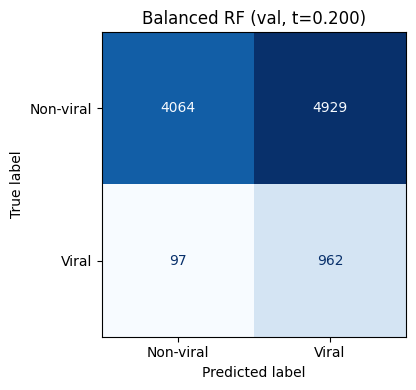

In [33]:
# # retrain best config on full training set
# print("\nRetraining best config on full training set...")
# rf_best = BalancedRandomForestClassifier(
#     **rf_grid.best_params_,
#     random_state=42,
#     n_jobs=1,
# )

rf_best = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=1,
)
start = time.perf_counter()
rf_best.fit(X_train, y_train)
print(f"Full retrain done in {time.perf_counter() - start:.1f}s")

# evaluate on val
rf_proba     = rf_best.predict_proba(X_val)[:, 1]
from sklearn.metrics import classification_report, f1_score
for t in [0.3, 0.4, 0.5]:
    preds = (rf_proba >= t).astype(int)
    mf1 = f1_score(y_val, preds, average='macro')
    print(f"threshold={t}: macro_f1={mf1:.3f}")
    print(classification_report(y_val, preds, target_names=['Non-viral','Viral']))
rf_threshold = find_optimal_threshold(y_val, rf_proba)
rf_results   = evaluate_model('Balanced RF (val)', y_val, rf_proba, rf_threshold)
# rf_results.update({
#     'model':        'balanced_random_forest',
#     'split':        'val',
#     'best_params':  rf_grid.best_params_,
#     'cv_pr_auc':    round(rf_grid.best_score_, 4),
#     'note':         'grid search on 50k subsample, final model trained on full dataset',
# })

plot_confusion_matrix(y_val, rf_proba, rf_threshold,
                      f'Balanced RF (val, t={rf_threshold:.3f})',
                      '../results/rf_confusion_matrix.png')
# joblib.dump(rf_best, '../models/rf_best.pkl')

# with open('../results/rf_results.json', 'w') as f:
#     json.dump(rf_results, f, indent=2, default=str)
# print("Saved")

### 3.2 XGBoost

scale_pos_weight: 9.00
threshold=0.3: macro_f1=0.463
              precision    recall  f1-score   support

   Non-viral       0.97      0.49      0.65      8993
       Viral       0.17      0.87      0.28      1059

    accuracy                           0.53     10052
   macro avg       0.57      0.68      0.46     10052
weighted avg       0.88      0.53      0.61     10052

threshold=0.4: macro_f1=0.495
              precision    recall  f1-score   support

   Non-viral       0.96      0.56      0.70      8993
       Viral       0.17      0.79      0.28      1059

    accuracy                           0.58     10052
   macro avg       0.57      0.67      0.49     10052
weighted avg       0.88      0.58      0.66     10052

threshold=0.5: macro_f1=0.529
              precision    recall  f1-score   support

   Non-viral       0.94      0.65      0.77      8993
       Viral       0.18      0.67      0.29      1059

    accuracy                           0.65     10052
   macro avg   

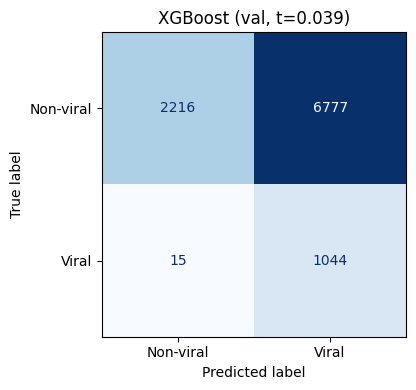

In [34]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() # n_viral / n_non-viral
print(f'scale_pos_weight: {scale_pos_weight:.2f}')


# print('Grid search for XGBoost')
# xgb_param_grid = {
#     'max_depth':     [3, 6],
#     'learning_rate': [0.05, 0.1],
# }

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=1,
    eval_metric='aucpr',
    verbosity=0,
)

# xgb_grid = GridSearchCV(
#     xgb_base,
#     xgb_param_grid,
#     cv=cv,
#     scoring='average_precision',
#     n_jobs=1,
#     verbose=1,
# )

start = time.perf_counter()
xgb_base.fit(X_train, y_train)
# print(f"Done in {time.perf_counter() - start:.1f}s")
# print(f"Best params: {xgb_grid.best_params_}")
# print(f"Best val PR-AUC: {xgb_grid.best_score_:.4f}")

# xgb_best      = xgb_grid.best_estimator_
xgb_best = xgb_base # just use the base version for now without gird search
xgb_proba     = xgb_best.predict_proba(X_val)[:, 1]
for t in [0.3, 0.4, 0.5]:
    preds = (xgb_proba >= t).astype(int)
    mf1 = f1_score(y_val, preds, average='macro')
    print(f"threshold={t}: macro_f1={mf1:.3f}")
    print(classification_report(y_val, preds, target_names=['Non-viral','Viral']))
xgb_threshold = find_optimal_threshold(y_val, xgb_proba)
xgb_results   = evaluate_model('XGBoost (val)', y_val, xgb_proba, xgb_threshold)
# xgb_results.update({
#     'model':             'xgboost',
#     'split':             'val',
#     'best_params':       xgb_grid.best_params_,
#     'cv_pr_auc':         round(xgb_grid.best_score_, 4),
#     'scale_pos_weight':  round(scale_pos_weight, 2),
# })

plot_confusion_matrix(y_val, xgb_proba, xgb_threshold,
                      f'XGBoost (val, t={xgb_threshold:.3f})',
                      '../results/xgb_confusion_matrix.png')

# with open('../results/xgb_results.json', 'w') as f:
#     json.dump(xgb_results, f, indent=2, default=str)
# print("Saved to ../results/xgb_results.json")


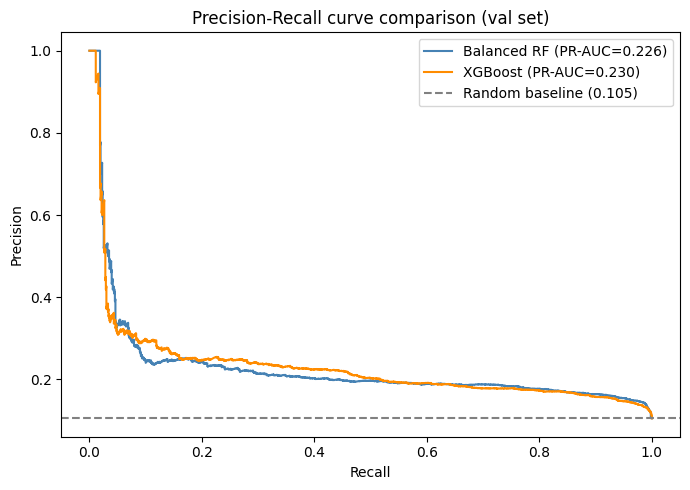

In [35]:
fig, ax = plt.subplots(figsize=(7, 5))
for proba, label, colour in [
    (rf_proba,  'Balanced RF', 'steelblue'),
    (xgb_proba, 'XGBoost',     'darkorange'),
]:
    p, r, _ = precision_recall_curve(y_val, proba)
    pr_auc = average_precision_score(y_val, proba)
    ax.plot(r, p, colour, label=f'{label} (PR-AUC={pr_auc:.3f})')

baseline = y_val.mean()
ax.axhline(baseline, linestyle='--', color='grey',
           label=f'Random baseline ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curve comparison (val set)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/pr_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 4 Feature importance

In [36]:
Path('../results/shap').mkdir(parents=True, exist_ok=True)

explainer   = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_val)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Mean prediction (base value): {explainer.expected_value:.4f}")

SHAP values shape: (10052, 21)
Mean prediction (base value): -0.0277


Check - model probabilities and SHAP sum + mean prediciton should be almost equal. SHAP values for each post should sum to the model's log-odds output. Convert to probabilities to perform check

- As expected, the two outputs match

In [37]:
# convert SHAP log-odds sum to probability
shap_sum_logodds = shap_values[:5].sum(axis=1) + explainer.expected_value
shap_sum_proba = scipy.special.expit(shap_sum_logodds)  # sigmoid transform

print(f"Model proba:    {xgb_best.predict_proba(X_val[:5])[:, 1].round(3)}")
print(f"SHAP sum+base:  {shap_sum_proba.round(3)}")

Model proba:    [0.68  0.597 0.59  0.65  0.466]
SHAP sum+base:  [0.68  0.597 0.59  0.65  0.466]


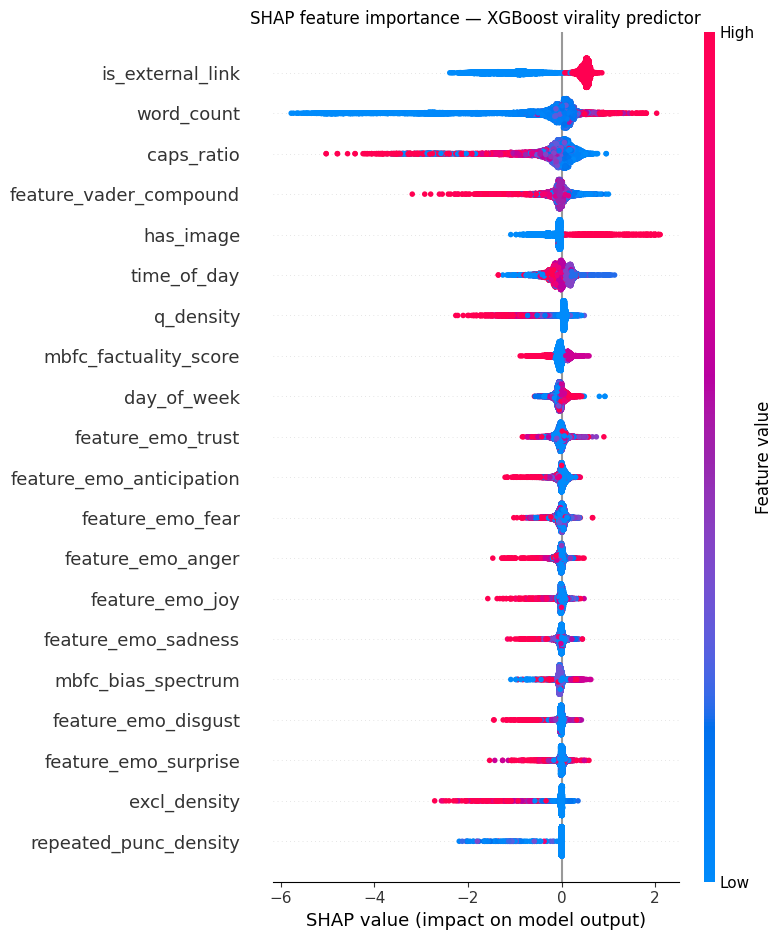

In [38]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_val,
    feature_names=UK_FEATURE_COLS,
    show=False,
    max_display=20,
)
plt.title('SHAP feature importance — XGBoost virality predictor')
plt.tight_layout()
plt.savefig('../results/shap/uk_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()


SHAP beeswarm plot
- global feature importance and directional effect of each feature on model's predictions
- Positive - pushed towards viral, negative - pushed away from viral, 0 - no effect
- Colour is the feature's value for that post (each dot is a post in the dataset)

Results
- `is_external_link` is the most important feature. Has link (1, red) clusteron the right (positive SHAP, push towards viral), while no link (blue, 0), lie below 0. Posts linking to external content are more likely to go viral than self-posts on politcal subreddits. Intuitive - news posts more likely to go viral than a discussion post
= `word_count` - wide spread. Shorter posts (blue) spread towards negative values, while short (red) lie positive. Aligns with Barnes et al - short posts go more viral than long ones - brevity matters 
- `caps_ratio` - red dots, high caps ration cluster strongly left. High caps ratio suggestive of highly emotive posts, might expect to go viral. But also likely to be spam/clickbait, which moderators are likely to remove or communities downvote
- `feature_vader_compound` — positive sentiment pushes toward virality (red right, blue left). Counterintuitive because suggests UK political viral content skews positive, not negative, as misinformation literature predicts. May reflect that factual, constructive news gets more engagement than outrage-driven content on these subreddits.
- `q_density` — high question mark density suppresses virality. Discussion-seeking posts underperform news-sharing posts.
- `feature_emo_trust` — high trust language marginally boosts virality, could be consistent with finding that fake content mimics credible-source language (reference)
- `has_image` - image posts more viral than text-only
- Emotion features (fear, anger, joy, sadness, anticipation, disgust, surprise) all show modest, near-zero SHAP values — emotional content is not a primary driver of virality on UK political Reddit at this stage. Pattern may change once p_fake and political leaning features are added.
- MBFC credibility features (`mbfc_factuality_score`, `mbfc_bias_spectrum`) show minimal SHAP — consistent with 92% sparsity in domain ratings. Only around 8% of posts link to MBFC-rated domains.

Overall, initial results show that structural features dominate of credibility/emotional features

In [39]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': UK_FEATURE_COLS,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False)

print("\nFeature importance (mean |SHAP|)")
print(importance_df.to_string(index=False))
importance_df.to_csv('../results/shap/feature_importance.csv', index=False)


Feature importance (mean |SHAP|)
                 feature  mean_abs_shap
        is_external_link       0.743410
              word_count       0.721168
              caps_ratio       0.399780
  feature_vader_compound       0.181856
               has_image       0.177908
             time_of_day       0.169159
               q_density       0.147560
   mbfc_factuality_score       0.092337
             day_of_week       0.076238
       feature_emo_trust       0.075434
feature_emo_anticipation       0.073367
        feature_emo_fear       0.072878
       feature_emo_anger       0.058455
         feature_emo_joy       0.058111
     feature_emo_sadness       0.055547
      mbfc_bias_spectrum       0.053028
     feature_emo_disgust       0.047727
    feature_emo_surprise       0.047256
            excl_density       0.033881
   repeated_punc_density       0.014500
              is_weekend       0.000000


### Topic features 

Run BERTopic on training set - better to use for analysis post SHAP? Can segment SHAP results by topic
  - Do viral rates differ by topic cluster?
  - Does the virality-misinformation relationship (SHAP value of p_fake) 
    differ across topic clusters?
  - Which topics are dominated by trigger words?
  - Are certain topics associated with higher political_lean_rati